In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
    
    
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
#import MyHaloPS as ps
import importlib
#importlib.reload(ps)
import pickle
import halofit_colossus as hf


In [4]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [5]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2


In [6]:
from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck15')
logks = np.arange(-1.5,1.5,0.01)
ks = 10**logks
kcoef = ks**3/(2*np.pi**2)
Pk_lin0 = cosmo.matterPowerSpectrum(ks, 0)
Pk_lin18 = cosmo.matterPowerSpectrum(ks, 18.3)


Deleted outdated persistence file, no further action needed (/cosma/home/dp004/dc-zhan5/.colossus/cache/cosmology/planck15_01025226215067a4148b3ddb0d531324, versions 1.2.10/1.0.0).


In [7]:
pk_hf0 = hf.pk_halofit(ks, 0, cosmo)
pk_hf18 = hf.pk_halofit(ks, 18.3, cosmo)

Text(0.5, 0, '$\\mathrm{log}_{10}(k\\ \\mathrm{[h\\ Mpc^{-1}]})$')

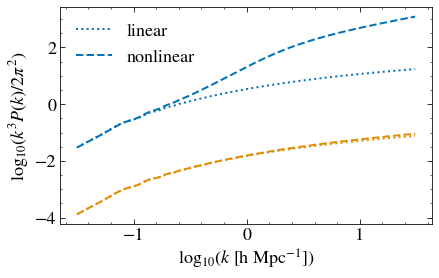

In [8]:
plt.plot(logks, np.log10(kcoef*Pk_lin0), label="linear", color=palette_tab10[0],linestyle="dotted")
plt.plot(logks, np.log10(kcoef*pk_hf0), label="nonlinear", color=palette_tab10[0],linestyle="dashed")
plt.plot(logks, np.log10(kcoef*Pk_lin18), color=palette_tab10[1],linestyle="dotted")
plt.plot(logks, np.log10(kcoef*pk_hf18),  color=palette_tab10[1],linestyle="dashed")
plt.legend()
plt.ylabel(r"$\mathrm{log}_{10}(k^3 P(k)/2\pi^2)$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h\ Mpc^{-1}]})$")

Text(0.5, 0, '$\\mathrm{log}_{10}(k\\ \\mathrm{[h\\ Mpc^{-1}]})$')

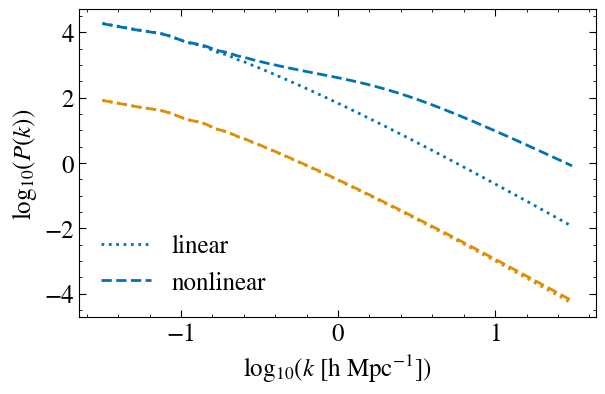

In [28]:
plt.plot(logks, np.log10(Pk_lin0), label="linear", color=palette_tab10[0],linestyle="dotted")
plt.plot(logks, np.log10(pk_hf0), label="nonlinear", color=palette_tab10[0],linestyle="dashed")
plt.plot(logks, np.log10(Pk_lin18), color=palette_tab10[1],linestyle="dotted")
plt.plot(logks, np.log10(pk_hf18),  color=palette_tab10[1],linestyle="dashed")
plt.legend()
plt.ylabel(r"$\mathrm{log}_{10}(P(k))$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h\ Mpc^{-1}]})$")

In [9]:

odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

#odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-group_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sum10 = pickle.load(f)

shotnoise 130.52360745197086


In [10]:
ks_tng = Pk_gal10["k"]
logks_tng = np.log10(ks_tng)
kcoef_tng = ks_tng**3/(2*np.pi**2)

In [11]:
Pk_lin15 = cosmo.matterPowerSpectrum(ks, 1.5)
pk_hf15 = hf.pk_halofit(ks, 1.5, cosmo)

(-1.5, 1.5)

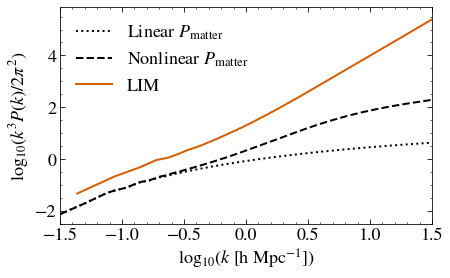

In [56]:
plt.plot(logks, np.log10(kcoef*Pk_lin15), label="Linear $P_{\mathrm{matter}}$", color="k",linestyle="dotted")
plt.plot(logks, np.log10(kcoef*pk_hf15), label="Nonlinear $P_{\mathrm{matter}}$", color="k",linestyle="dashed")
plt.plot(logks_tng, np.log10(kcoef_tng*Pk_gal10["power"].real), color=palette_tab10[3], label="LIM")
plt.ylabel(r"$\mathrm{log}_{10}(k^3 P(k)/2\pi^2)$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h\ Mpc^{-1}]})$")
plt.legend()
plt.xlim([-1.5,1.5])

(-1.5, 1.5)

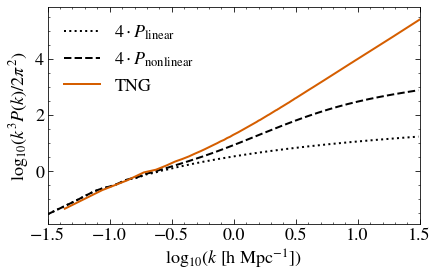

In [53]:
plt.plot(logks, np.log10(4*kcoef*Pk_lin15), label="$4 \cdot P_{\mathrm{linear}}$", color="k",linestyle="dotted")
plt.plot(logks, np.log10(4*kcoef*pk_hf15), label="$4 \cdot P_{\mathrm{nonlinear}}$", color="k",linestyle="dashed")
plt.plot(logks_tng, np.log10(kcoef_tng*Pk_gal10["power"].real), color=palette_tab10[3], label="TNG")
plt.ylabel(r"$\mathrm{log}_{10}(k^3 P(k)/2\pi^2)$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h\ Mpc^{-1}]})$")
plt.legend()
plt.xlim([-1.5,1.5])

In [13]:
halo2 = Pk_sum10["power"] - Pk_sum10.attrs["shotnoise"]
halo1 = Pk_gal10["power"] - halo2

/cosma/home/dp004/dc-zhan5/anaconda3/envs/nbodykit-env/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/home/dp004/dc-zhan5/anaconda3/envs/nbodykit-env/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


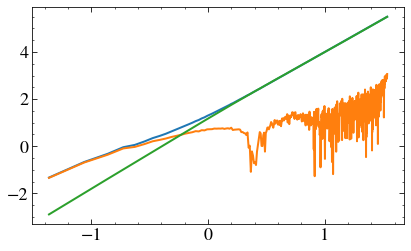

In [67]:
plt.plot(logks_tng, np.log10(kcoef_tng*Pk_gal10["power"].real))
plt.plot(logks_tng, np.log10(kcoef_tng*halo2))
plt.plot(logks_tng, np.log10(kcoef_tng*halo1))



/cosma/home/dp004/dc-zhan5/anaconda3/envs/nbodykit-env/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/home/dp004/dc-zhan5/anaconda3/envs/nbodykit-env/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


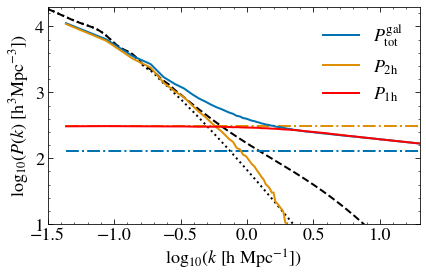

In [89]:
plt.plot(logks, np.log10(4*Pk_lin15), color="k",linestyle="dotted")
plt.plot(logks, np.log10(4*pk_hf15),  color="k",linestyle="dashed")

plt.plot(logks_tng, [np.log10((Pk_gal10.attrs["shotnoise"]))]*len(logks_tng), linestyle="dashdot", c=palette_tab10[0])
plt.plot(logks_tng, [np.log10((Pk_sum10.attrs["shotnoise"]))]*len(logks_tng), linestyle="dashdot", c=palette_tab10[1])

plt.plot(logks_tng, np.log10(Pk_gal10["power"].real),  color=palette_tab10[0], label="$P^{\mathrm{gal}}_{\mathrm{tot}}$")
plt.plot(logks_tng, np.log10(halo2),  color=palette_tab10[1], label="$P_{\mathrm{2h}}$")
plt.plot(logks_tng, np.log10(halo1),  color="red", label="$P_{\mathrm{1h}}$")



plt.xlim(-1.5,1.3)
plt.ylim(1, 4.3)

plt.ylabel(r"$\mathrm{log}_{10}(P(k)\ [\mathrm{h^3 Mpc^{-3}}])$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h\ Mpc^{-1}]})$")
plt.legend()

/cosma/home/dp004/dc-zhan5/anaconda3/envs/nbodykit-env/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


Text(0.5, 0, '$\\mathrm{log}_{10}(k\\ \\mathrm{[h\\ Mpc^{-1}]})$')

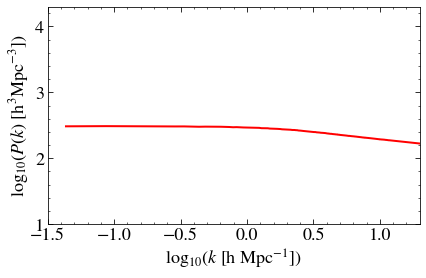

In [16]:
# plt.plot(logks, np.log10(4*Pk_lin15), color="k",linestyle="dotted")
# plt.plot(logks, np.log10(4*pk_hf15),  color="k",linestyle="dashed")

# plt.plot(logks_tng, [np.log10((Pk_gal10.attrs["shotnoise"]))]*len(logks_tng), linestyle="dashdot", c=palette_tab10[0])
# plt.plot(logks_tng, [np.log10((Pk_sum10.attrs["shotnoise"]))]*len(logks_tng), linestyle="dashdot", c=palette_tab10[1])

#plt.plot(logks_tng, np.log10(Pk_gal10["power"].real),  color=palette_tab10[0], label="$P^{\mathrm{gal}}_{\mathrm{tot}}$")
#plt.plot(logks_tng, np.log10(halo2),  color=palette_tab10[1], label="$P_{\mathrm{2h}}$")
plt.plot(logks_tng, np.log10(halo1),  color="red", label="$P_{\mathrm{1h}}$")



plt.xlim(-1.5,1.3)
plt.ylim(1, 4.3)

plt.ylabel(r"$\mathrm{log}_{10}(P(k)\ [\mathrm{h^3 Mpc^{-3}}])$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h\ Mpc^{-1}]})$")
#plt.legend()

/cosma/home/dp004/dc-zhan5/anaconda3/envs/nbodykit-env/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


Text(0.5, 0, '$\\mathrm{log}_{10}(k\\ \\mathrm{[h\\ Mpc^{-1}]})$')

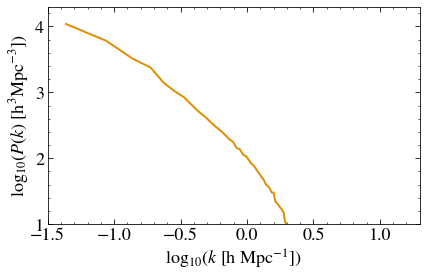

In [17]:
# plt.plot(logks, np.log10(4*Pk_lin15), color="k",linestyle="dotted")
# plt.plot(logks, np.log10(4*pk_hf15),  color="k",linestyle="dashed")

# plt.plot(logks_tng, [np.log10((Pk_gal10.attrs["shotnoise"]))]*len(logks_tng), linestyle="dashdot", c=palette_tab10[0])
# plt.plot(logks_tng, [np.log10((Pk_sum10.attrs["shotnoise"]))]*len(logks_tng), linestyle="dashdot", c=palette_tab10[1])

#plt.plot(logks_tng, np.log10(Pk_gal10["power"].real),  color=palette_tab10[0], label="$P^{\mathrm{gal}}_{\mathrm{tot}}$")
plt.plot(logks_tng, np.log10(halo2),  color=palette_tab10[1], label="$P_{\mathrm{2h}}$")
#plt.plot(logks_tng, np.log10(halo1),  color="red", label="$P_{\mathrm{1h}}$")



plt.xlim(-1.5,1.3)
plt.ylim(1, 4.3)

plt.ylabel(r"$\mathrm{log}_{10}(P(k)\ [\mathrm{h^3 Mpc^{-3}}])$")
plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h\ Mpc^{-1}]})$")
#plt.legend()